# 2.0 Face Dataset Audit and Cleaning

Purpose:
- Load the existing face image manifest
- Compute exact file hashes
- Detect duplicate images
- Detect cross-class duplicates
- Create a cleaned face manifest for modeling

This notebook is part of the data engineering phase. It does not train a model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from rural_stroke_assist.config import (
    FACE_INTERIM_MANIFEST_PATH,
    FACE_DUPLICATE_REPORT_PATH,
    FACE_CLEAN_MANIFEST_PATH,
    FIGURES_DIR,
)
from rural_stroke_assist.preprocessing.face_audit import (
    add_file_hashes,
    create_duplicate_report,
    mark_duplicate_status,
    create_clean_face_manifest,
    summarize_duplicate_audit,
)
from rural_stroke_assist.plots import save_bar_plot

In [2]:
face_df = pd.read_csv(FACE_INTERIM_MANIFEST_PATH)

face_df.head()

,path,file_name,class_label,extension,readable,width,height
0,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0022.jpg,NonStroke,.jpg,True,299,169
1,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0024.jpg,NonStroke,.jpg,True,379,379
2,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0025.jpg,NonStroke,.jpg,True,275,183
3,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0027.jpg,NonStroke,.jpg,True,163,222
4,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0030.jpg,NonStroke,.jpg,True,342,382


In [3]:
print("Rows:", len(face_df))
print("Columns:", face_df.columns.tolist())
print(face_df["class_label"].value_counts())

Rows: 3749
Columns: ['path', 'file_name', 'class_label', 'extension', 'readable', 'width', 'height']
class_label
NonStroke    2500
Stroke       1249
Name: count, dtype: int64


In [4]:
face_df_hashed = add_file_hashes(face_df)

face_df_hashed.head()

,path,file_name,class_label,extension,readable,width,height,file_hash
0,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0022.jpg,NonStroke,.jpg,True,299,169,a3e6d954dd74d17e89c497d4967c93366d623b4b5b694f...
1,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0024.jpg,NonStroke,.jpg,True,379,379,b2a1a613cdb309d96a998ed46adea5fe182aa661a40c88...
2,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0025.jpg,NonStroke,.jpg,True,275,183,7038e96c4cafff98b47b9df614b9cd51473476e4d99699...
3,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0027.jpg,NonStroke,.jpg,True,163,222,b9a1bd4960d3afa939c7f908c1d821c468ebd247e92f50...
4,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0030.jpg,NonStroke,.jpg,True,342,382,bac0af9d5eef5722d3b989d1e29677f6d4b479bda29748...


In [5]:
duplicate_report = create_duplicate_report(face_df_hashed)

duplicate_report.head()

,file_hash,file_count,class_count,labels,paths,is_duplicate,is_cross_class_duplicate
894,6b84f1558385341899861a13489e843236259f5663cc96...,2,2,"[NonStroke, Stroke]",[C:\Users\Asus\Downloads\Uni_work\Grad-Project...,True,True
149,12a135a290fcb93342aa7e77286ff6b0e03d08888a7403...,3,1,[NonStroke],[C:\Users\Asus\Downloads\Uni_work\Grad-Project...,True,False
197,197b6758d55b3f52e32def4b77ac5ef1ef37a0decb9105...,3,1,[NonStroke],[C:\Users\Asus\Downloads\Uni_work\Grad-Project...,True,False
408,323621e29618129fe8f0224e46a0c2c37387af33f982bb...,3,1,[NonStroke],[C:\Users\Asus\Downloads\Uni_work\Grad-Project...,True,False
484,3ace7d7224579855843cdc9ed309f661b01dfd0351fbad...,3,1,[NonStroke],[C:\Users\Asus\Downloads\Uni_work\Grad-Project...,True,False


In [6]:
clean_face_df = create_clean_face_manifest(face_df_hashed)

audit_summary = summarize_duplicate_audit(
    manifest=face_df_hashed,
    duplicate_report=duplicate_report,
    clean_manifest=clean_face_df,
)

audit_summary

{'total_files': 3749,
 'unique_hashes': 2116,
 'duplicate_extra_files': 1633,
 'duplicate_extra_percentage': 43.56,
 'cross_class_duplicate_hashes': 1,
 'clean_files': 2115,
 'removed_files': 1634}

In [7]:
cross_class_duplicates = duplicate_report[
    duplicate_report["is_cross_class_duplicate"]
]

cross_class_duplicates

,file_hash,file_count,class_count,labels,paths,is_duplicate,is_cross_class_duplicate
894,6b84f1558385341899861a13489e843236259f5663cc96...,2,2,"[NonStroke, Stroke]",[C:\Users\Asus\Downloads\Uni_work\Grad-Project...,True,True


In [8]:
face_df_audited = mark_duplicate_status(
    manifest=face_df_hashed,
    duplicate_report=duplicate_report,
)

face_df_audited.head()

,path,file_name,class_label,extension,readable,width,height,file_hash,file_count,class_count,is_duplicate,is_cross_class_duplicate
0,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0022.jpg,NonStroke,.jpg,True,299,169,a3e6d954dd74d17e89c497d4967c93366d623b4b5b694f...,2,1,True,False
1,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0024.jpg,NonStroke,.jpg,True,379,379,b2a1a613cdb309d96a998ed46adea5fe182aa661a40c88...,2,1,True,False
2,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0025.jpg,NonStroke,.jpg,True,275,183,7038e96c4cafff98b47b9df614b9cd51473476e4d99699...,2,1,True,False
3,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0027.jpg,NonStroke,.jpg,True,163,222,b9a1bd4960d3afa939c7f908c1d821c468ebd247e92f50...,2,1,True,False
4,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0030.jpg,NonStroke,.jpg,True,342,382,bac0af9d5eef5722d3b989d1e29677f6d4b479bda29748...,2,1,True,False


In [9]:
before_counts = face_df_hashed["class_label"].value_counts()
before_counts

class_label
NonStroke    2500
Stroke       1249
Name: count, dtype: int64

In [10]:
after_counts = clean_face_df["class_label"].value_counts()
after_counts

class_label
NonStroke    1386
Stroke        729
Name: count, dtype: int64

In [11]:
comparison_df = pd.DataFrame(
    {
        "before_cleaning": before_counts,
        "after_cleaning": after_counts,
    }
)

comparison_df["removed"] = (
    comparison_df["before_cleaning"] - comparison_df["after_cleaning"]
)

comparison_df

,before_cleaning,after_cleaning,removed
class_label,,,
NonStroke,2500,1386,1114
Stroke,1249,729,520


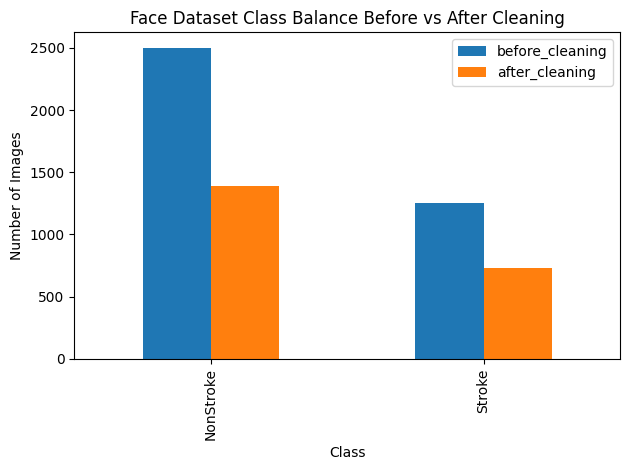

In [12]:
comparison_df[["before_cleaning", "after_cleaning"]].plot(
    kind="bar",
    title="Face Dataset Class Balance Before vs After Cleaning",
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [13]:
FACE_DUPLICATE_REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
FACE_CLEAN_MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)

duplicate_report.to_csv(FACE_DUPLICATE_REPORT_PATH, index=False)
clean_face_df.to_csv(FACE_CLEAN_MANIFEST_PATH, index=False)

print("Saved duplicate report to:", FACE_DUPLICATE_REPORT_PATH)
print("Saved clean manifest to:", FACE_CLEAN_MANIFEST_PATH)

Saved duplicate report to: C:\Users\Asus\Downloads\Uni_work\Grad-Project\rural-stroke-assist\data\interim\face_duplicate_report.csv
Saved clean manifest to: C:\Users\Asus\Downloads\Uni_work\Grad-Project\rural-stroke-assist\data\processed\face_clean_manifest.csv


In [14]:
comparison_path = FACE_CLEAN_MANIFEST_PATH.parent / "face_cleaning_class_balance.csv"
comparison_df.to_csv(comparison_path)

print("Saved class balance comparison to:", comparison_path)

Saved class balance comparison to: C:\Users\Asus\Downloads\Uni_work\Grad-Project\rural-stroke-assist\data\processed\face_cleaning_class_balance.csv


## Face Dataset Cleaning Decisions

Cleaning strategy:

1. Exact duplicate detection was performed using SHA256 file hashes.
2. Cross-class duplicates were removed entirely because they represent conflicting labels.
3. Same-class duplicates were deduplicated by keeping one representative image per hash.
4. The cleaned manifest is saved under `data/processed`, while the raw data remains unchanged.

This preserves the principle that `data/raw` is immutable and all cleaning outputs are reproducible.